Wymiary bazy :  (620, 8)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   link            620 non-null    object 
 1   Data-Name       620 non-null    object 
 2   data type       617 non-null    object 
 3   default task    591 non-null    object 
 4   attribute-type  483 non-null    object 
 5   instances       586 non-null    float64
 6   attributes      557 non-null    float64
 7   year            589 non-null    float64
dtypes: float64(3), object(5)
memory usage: 38.9+ KB


Puste komorki:


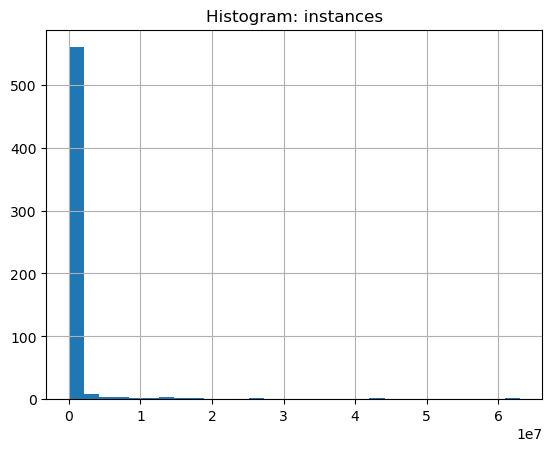

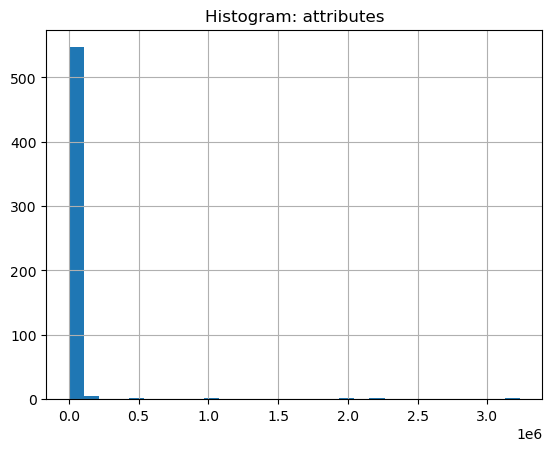

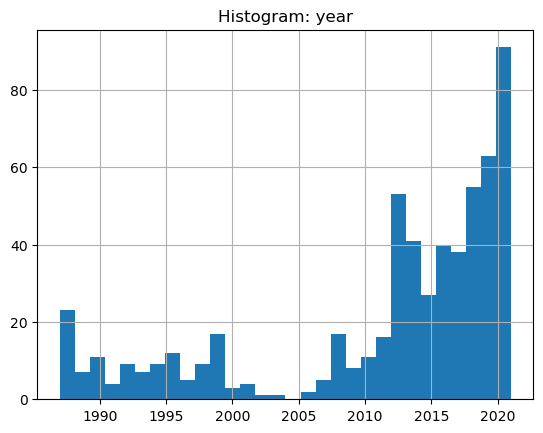

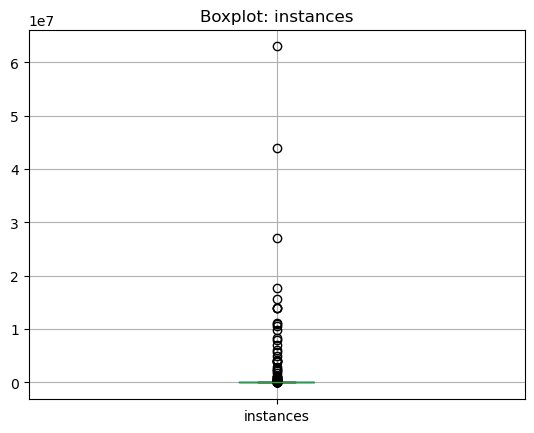

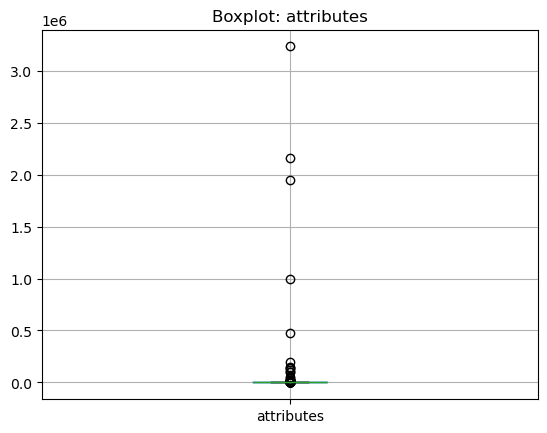

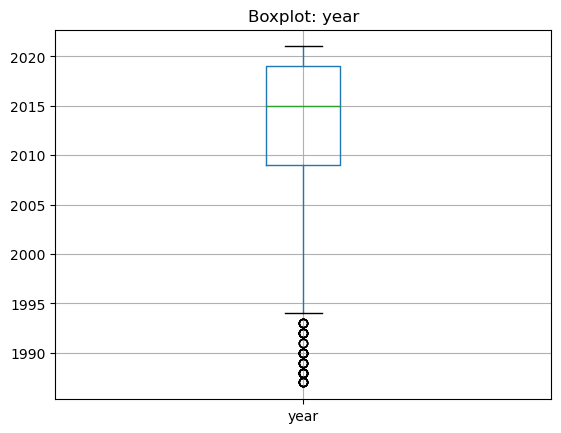

0.13709677419354838
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, confusion_matrix

df = pd.read_csv('UCI-datset.csv')
df.head()

print("Wymiary bazy : ", df.shape)
print("\n")

df.info()
print("\n")

df.describe(include='all')

print("Puste komorki:")
df.isna().sum()


numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f'Histogram: {col}')
    plt.show()

for col in numeric_cols:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


corr = df.corr(numeric_only=True)
corr.head()


data = df.copy()

# Przykład: wypełnienie braków medianą w wybranych kolumnach numerycznych
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

# Przykład: uzupełnienie braków w kolumnie kategorycznej stałą wartością
cat_cols = data.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    data[col] = data[col].fillna('brak_danych')


data_encoded = pd.get_dummies(data, drop_first=True)
data_encoded.head()

X = data_encoded.drop('attributes', axis=1)  # podmień 'target' na nazwę kolumny docelowej
y = data_encoded['attributes']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)



X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_clf, y_train_clf)

y_pred_clf = clf.predict(X_test_clf)

acc = accuracy_score(y_test_clf, y_pred_clf)
cm = confusion_matrix(y_test_clf, y_pred_clf)

print(acc)
print(cm)

